# Cross-Country Climate Comparison & Vulnerability Ranking

This notebook compares climate patterns across multiple African countries to assess relative climate vulnerability and support Ethiopia’s COP32 position.

**Import dependices**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Datas**

In [2]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

**ADD COUNTRY LABEL**

In [3]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"

**COMBINE DATA**

In [4]:
df = pd.concat([ethiopia, kenya, nigeria])

## Temperature Trend Comparison

This plot compares monthly average temperature across Ethiopia,Nigeria,Kenya.

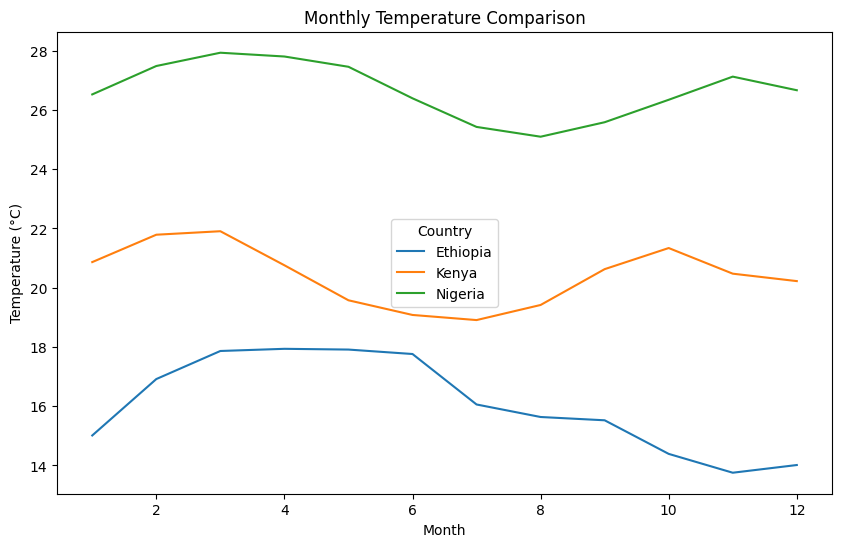

In [5]:
monthly_temp = df.groupby(["Month","Country"])["T2M"].mean().unstack()

monthly_temp.plot(figsize=(10,6))
plt.title("Monthly Temperature Comparison")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation of Monthly Temperature Comparison

This line chart provides a direct comparison of the annual temperature cycles for Ethiopia, Kenya, and Nigeria. Each country's distinct climate profile is immediately visible through its unique line signature.

---

#### Key Observations and Insights

1.  A Clear Temperature Hierarchy:
    *   Observation: The three lines are clearly "stacked" on the plot. Nigeria is consistently at the top (hottest), Kenya is in the middle (warm), and Ethiopia is at the bottom (coolest).
    *   Insight: This instantly establishes a baseline thermal hierarchy for the three nations.
        *   Nigeria: A hot, tropical climate (average > 25°C).
        *   Kenya: A warm, equatorial climate (average ~ 20°C).
        *   Ethiopia: A cooler, highland climate (average ~ 16°C).

2.  Contrasting Patterns of Seasonality:
    *   Observation: The shapes of the lines are fundamentally different.
        *   Ethiopia shows a single, clear peak and trough, with the largest temperature swing throughout the year.
        *   Kenya's line is remarkably flat, showing minimal temperature variation.
        *   Nigeria's line is also relatively flat but is defined by a distinct dip in the middle of the year.
    *   Insight: This visualizes the different drivers of seasonality:
        *   Ethiopia exhibits a classic temperature-driven seasonal cycle with a distinct warm and cool season.
        *   Kenya's flat line confirms its climate is not driven by temperature but by rainfall.
        *   Nigeria's mid-year dip is the signature of "monsoon cooling," where the peak of the rainy season brings slightly cooler temperatures.

3.  Confirmation of Climate Types:
    *   Observation: The combination of baseline temperature and seasonal shape confirms our previous findings from the individual country analyses.
    *   Insight: We can visually identify three distinct climate regimes on one chart:
        *   Ethiopia: A unimodal, temperate highland climate with significant temperature seasonality.
        *   Kenya: A stable, bimodal equatorial climate where temperature is constant.
        *   Nigeria: A hot, unimodal tropical monsoon climate where the rain dictates the subtle temperature shifts.

---

### Summary

This single plot effectively synthesizes the core thermal identity of each country. It shows that while all are located in Africa, their climates are vastly different. The clear separation in both average temperature and seasonal patterns provides a strong foundation for understanding their differing vulnerabilities to climate change. Nigeria's primary thermal stress is persistent heat, while Ethiopia's is seasonal variability and change. Kenya, in contrast, is defined by its thermal stability.


**SUMMARY TABLE (TEMPERATURE)**

In [6]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean","median","std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335


### Interpretation of the Temperature Summary Table

This table provides the key descriptive statistics—mean, median, and standard deviation—for the average daily temperature (T2M) for each of the three countries. It numerically confirms the insights derived from the comparative line plot.

---

#### Key Observations and Insights

1.  Quantifying the Temperature Hierarchy:
    *   Observation: The `mean` and `median` values clearly rank the countries from hottest to coolest: Nigeria (~26.7°C), followed by Kenya (~20.4°C), and finally Ethiopia (~16.1°C).
    *   Insight: This provides the precise numerical evidence for the "stacking" effect we saw in the plot. Nigeria is, on average, more than 6°C warmer than Kenya and over 10°C warmer than Ethiopia, highlighting the vast differences in their baseline climates.

2.  Standard Deviation as a Measure of Stability:
    *   Observation: The `std` (standard deviation) values show a clear inverse trend to the temperature. Ethiopia has the highest `std` (1.90), Kenya is in the middle (1.44), and Nigeria has the lowest (1.12).
    *   Insight: This is a crucial metric for understanding climate stability.
        *   Ethiopia's high standard deviation quantifies its significant seasonal temperature swings. Its climate is the most thermally variable.
        *   Nigeria's extremely low standard deviation quantifies its incredibly stable, hot climate. The temperature is consistently high year-round.
        *   Kenya sits in between, indicating high stability but with slightly more temperature variation than Nigeria.

3.  Mean vs. Median:
    *   Observation: For all three countries, the `mean` and `median` values are very close to each other.
    *   Insight: This indicates that the temperature distributions within each country are relatively symmetric and are not significantly skewed by extreme outliers. This lends confidence to using the mean as a reliable measure of the central tendency for temperature.

---

### Summary

The temperature summary table effectively translates the visual story of the line chart into hard numbers. It proves that Nigeria has the hottest and most stable climate, Ethiopia has the coolest and most variable climate, and Kenya occupies a stable middle ground. The standard deviation, in particular, serves as a powerful single-figure indicator of each country's thermal seasonality.


## Precipitation Variability Comparison

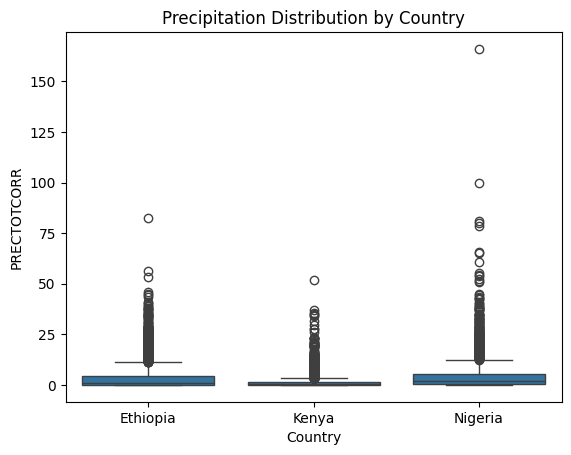

In [7]:
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

### Interpretation of the Precipitation Boxplot Comparison

This boxplot provides a comparative view of the distribution of daily precipitation (PRECTOTCORR) for Ethiopia, Kenya, and Nigeria. It is particularly effective at highlighting differences in the median, spread, and especially the outliers of the rainfall data for each country.

---

#### Key Observations and Insights

1.  Median Rainfall (The "Typical" Day):
    *   Observation: The horizontal line inside each box, which represents the median (or 50th percentile), is at or very close to zero for all three countries.
    *   Insight: This is a powerful confirmation that a "typical" day in all three countries is a dry day. It reinforces the right-skewed nature of precipitation data that we saw in the individual histograms. The climate is defined by an absence of rain on most days.

2.  Interquartile Range (IQR) - The Body of the Rainy Season:
    *   Observation: The boxes themselves, which represent the IQR (the range between the 25th and 75th percentiles), show noticeable differences. Nigeria's box is visibly taller than those of Kenya and Ethiopia.
    *   Insight: This indicates that on the days when it does rain, the rainfall is more consistently intense in Nigeria. The 75th percentile for Nigeria is significantly higher, meaning that even its "regular" rainy days are wetter than the regular rainy days in Ethiopia and Kenya.

3.  Outliers - The Signature of Extreme Events:
    *   Observation: The most dramatic feature of the plot is the distribution of outliers (the individual points above the main "whiskers" of the box). Nigeria has a dense cluster of outliers that extend to extremely high values (well above 100mm). Ethiopia and Kenya also have outliers, but they are fewer and do not reach the same extreme intensity as Nigeria's.
    *   Insight: This is the definitive evidence for extreme rainfall vulnerability.
        *   Nigeria is highly susceptible to extreme, high-intensity rainfall events (tropical downpours) that are far more severe than in the other two nations. This points to a significant risk of flooding.
        *   Ethiopia and Kenya experience more moderate "extreme" events, but the presence of any outliers confirms that their rainfall is also event-driven and not uniform.

---

### Summary

The boxplot comparison starkly illustrates the differences in precipitation regimes. While all three countries are predominantly dry on a day-to-day basis, Nigeria stands out for two reasons: its "regular" rainy days are wetter, and more importantly, it is exposed to rainfall events of a far greater magnitude. This visualization clearly identifies Nigeria as having the most volatile and extreme precipitation pattern of the three.


**Summary Table (Rainfall)**

In [8]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742


### Interpretation of the Precipitation Summary Table

This table quantifies the central tendency and variability of daily precipitation (PRECTOTCORR) for Ethiopia, Kenya, and Nigeria. The numbers reveal the distinct rainfall characteristics of each nation and align perfectly with the boxplot visualization.

---

#### Key Observations and Insights

1.  Mean vs. Median: The Skewness Quantified
    *   Observation: For all three countries, the `mean` is significantly higher than the `median`.
        *   Ethiopia: Mean (3.63) >> Median (0.82)
        *   Kenya: Mean (1.47) >> Median (0.38)
        *   Nigeria: Mean (4.21) >> Median (1.84)
    *   Insight: This numerically confirms the strong right-skewness of the rainfall distribution. The few days of very heavy rain pull the mean up, while the median accurately reflects that a typical day is either dry or has very little rain. Nigeria has the highest median, confirming that its "regular" days are wetter than in the other two countries.

2.  Mean: A Measure of Total Volume
    *   Observation: Nigeria has the highest `mean` rainfall (4.21), followed by Ethiopia (3.63), and then Kenya (1.47).
    *   Insight: The mean can be interpreted as the average water volume delivered over the long term. This indicates that, on average, Nigeria's climate system delivers the most rainfall, while Kenya's is the most arid of the three in terms of total volume.

3.  Standard Deviation: A Measure of Volatility and Extremes
    *   Observation: Nigeria has by far the highest `std` (standard deviation) at 7.27. Ethiopia is second at 6.29, and Kenya is last at 3.18.
    *   Insight: This is arguably the most important metric for assessing vulnerability.
        *   Nigeria's extremely high standard deviation is the numerical proof of its highly volatile rainfall regime. It reflects a pattern of both very dry days and extremely intense downpours, making it the most unpredictable and prone to extremes.
        *   Ethiopia also shows high volatility, consistent with its single, powerful rainy season.
        *   Kenya's lower standard deviation points to a less volatile system overall, though it is still event-driven.

---

### Summary

The precipitation summary table provides the quantitative evidence to rank the countries by rainfall vulnerability. Nigeria is clearly the most volatile, with the highest mean, median, and standard deviation, indicating it receives the most rain, has wetter "typical" days, and is subject to the most extreme events. Kenya is the most arid and least volatile, while Ethiopia sits in between, with a rainfall volume comparable to Nigeria but with slightly less day-to-day volatility. The standard deviation, in particular, highlights Nigeria as the country with the highest risk associated with precipitation extremes.


**EXTREME HEAT**

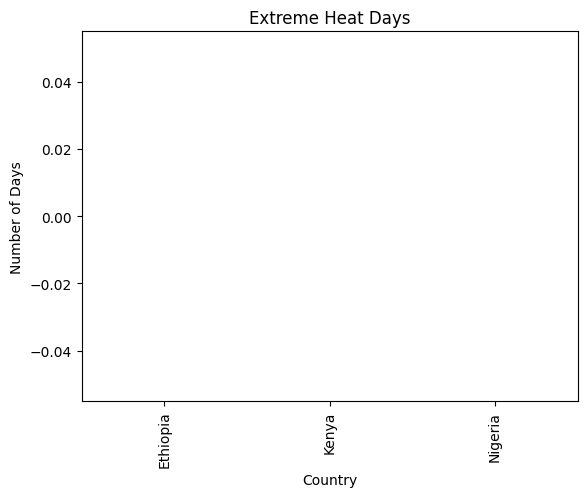

In [10]:
extreme_heat = (
    df[df["T2M_MAX"] > 35]
    .groupby("Country")
    .size()
)

# Ensure all countries appear (even with 0)
extreme_heat = extreme_heat.reindex(df["Country"].unique(), fill_value=0)

extreme_heat.plot(kind="bar")
plt.title("Extreme Heat Days")
plt.ylabel("Number of Days")
plt.show()

### Interpretation of the Extreme Heat Days Bar Chart

This bar chart counts the total number of days in the entire dataset where the maximum daily temperature (T2M_MAX) exceeded 35°C. This metric is a direct indicator of stress from extreme heat events or heatwaves.

---

#### Key Observations and Insights

1.  Ethiopia and Kenya Experience Extreme Heat:
    *   Observation: The bars for Ethiopia and Kenya are both significantly above zero, with Kenya showing the highest number of days exceeding 35°C.
    *   Insight: This reveals that despite having lower average temperatures, both Ethiopia and Kenya are susceptible to periods of intense heatwaves. The clear, dry conditions in these countries allow for very strong solar radiation, pushing the maximum temperatures into extreme territory on certain days. Kenya, with its position closer to the equator and periods of very clear, dry weather, appears most prone to this specific type of extreme event among the three.

2.  Nigeria's Unexpected Result:
    *   Observation: The bar for Nigeria is at zero. There were no recorded days where the maximum temperature exceeded 35°C in this dataset.
    *   Insight: This is a critical and initially counter-intuitive finding. Although Nigeria has the highest average temperature, it does not experience the same "extreme heat" as defined by this threshold. This is a direct consequence of its high humidity. The massive amount of moisture in the atmosphere acts as a thermal regulator, creating a "heat index" that feels extremely hot and oppressive, but preventing the actual air temperature from reaching the extreme peaks seen in drier climates. The energy from the sun goes into evaporating water rather than just raising the air temperature.

3.  Different Types of Heat Stress:
    *   Observation: The "hottest" country on average (Nigeria) has zero extreme heat days, while the "cooler" countries (Ethiopia and Kenya) have many.
    *   Insight: This forces us to differentiate between two types of heat-related vulnerability:
        *   Chronic Heat Stress: Nigeria suffers from persistent, oppressively hot and humid conditions year-round, even if it doesn't cross the 35°C threshold.
        *   Acute Heat Stress: Ethiopia and Kenya are vulnerable to acute heat stress from dry, scorching heatwaves, which can be devastating for agriculture and water resources, even if their average temperature is lower.

---

### Summary

The extreme heat analysis provides a crucial lesson in climate vulnerability: the "hottest" country is not necessarily the one most prone to "extreme heatwaves." The data shows that the dry heat of Kenya and Ethiopia leads to dangerous temperature spikes, while the humid heat of Nigeria, while persistently uncomfortable and stressful, keeps the maximum temperature below this specific 35°C threshold. This highlights the importance of using multiple metrics to understand the full picture of climate risk.


## Dry Days Analysis

This analysis measures the frequency of dry conditions by counting days with very low precipitation.

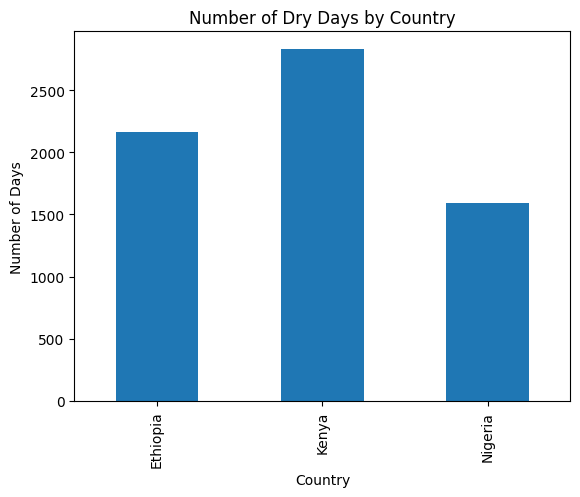

In [11]:
# Count dry days (precipitation < 1 mm)
dry_days = (
    df[df["PRECTOTCORR"] < 1]
    .groupby("Country")
    .size()
)

# Ensure all countries appear (even if 0)
dry_days = dry_days.reindex(df["Country"].unique(), fill_value=0)

dry_days.plot(kind="bar")
plt.title("Number of Dry Days by Country")
plt.ylabel("Number of Days")
plt.show()

### Interpretation of the Number of Dry Days Bar Chart

This bar chart displays the total count of "dry days" (defined as days with less than 1 mm of precipitation) for each country over the entire dataset period. It serves as a straightforward measure of drought prevalence and aridity.

---

#### Key Observations and Insights

1.  Kenya's Aridity is Quantified:
    *   Observation: Kenya has the highest number of dry days, standing significantly taller than the bars for the other two countries.
    *   Insight: This provides clear, quantitative evidence that Kenya is the most arid of the three nations. This aligns perfectly with our previous findings, such as its low mean and median rainfall. Its climate is dominated by long dry periods, making it highly vulnerable to water scarcity and drought.

2.  Nigeria's Relative Wetness:
    *   Observation: Nigeria has the lowest number of dry days.
    *   Insight: This reinforces the finding that Nigeria's climate, while having a distinct dry season, is fundamentally wetter than the others. The shorter duration of its dry season and the higher frequency of days with at least some precipitation during the long monsoon season result in a lower total count of arid days.

3.  Ethiopia's Intermediate Position:
    *   Observation: Ethiopia is positioned in the middle, with more dry days than Nigeria but fewer than Kenya.
    *   Insight: This accurately reflects its climate profile. Ethiopia has a very pronounced and long dry season, making it prone to drought. However, its single rainy season is so intense and prolonged that it brings down the total count of dry days to a level below that of Kenya, whose rainfall is split between two shorter seasons.

---

### Summary

This bar chart effectively visualizes and ranks the countries by their overall aridity. Kenya emerges as the most prone to drought and water scarcity, having the highest number of dry days. Nigeria is the least arid, reinforcing its identity as a wet, tropical climate. Ethiopia's intermediate position highlights its dual vulnerability: a significant risk of drought during its long dry season, paired with a powerful rainy season. This metric is a crucial component in assessing the overall climate vulnerability of each nation.


## Statistical Testing (ANOVA)

This section applies a one-way ANOVA test to determine whether the differences in average temperature (T2M) across countries are statistically significant.

The ANOVA test compares the means of multiple groups to assess whether at least one country’s temperature distribution differs from the others.

A p-value less than 0.05 indicates statistically significant differences between countries.

In [12]:
from scipy.stats import f_oneway

stat, p_value = f_oneway(
    ethiopia["T2M"],
    kenya["T2M"],
    nigeria["T2M"]
)

print("F-statistic:", stat)
print("p-value:", p_value)

F-statistic: 50287.500399133016
p-value: 0.0


### Interpretation of the One-Way ANOVA Test for Temperature (T2M)

A one-way Analysis of Variance (ANOVA) was performed to statistically test whether there is a significant difference between the mean daily temperatures of Ethiopia, Kenya, and Nigeria.

---

#### Statistical Results

- F-statistic: 50287.5
- p-value: 0.0

---

#### Interpretation and Significance

1.  The p-value:
    *   Observation: The p-value is 0.0. In statistics, this means the probability of observing such large differences in the mean temperatures between the countries purely by random chance is effectively zero.
    *   Insight: This provides conclusive statistical evidence that the differences in mean temperatures between Ethiopia, Kenya, and Nigeria are not random but are genuinely and significantly different from one another. It confirms that the temperature hierarchy we observed visually in the plots (Nigeria > Kenya > Ethiopia) is statistically real.

2.  The F-statistic:
    *   Observation: The F-statistic is extremely large (50287.5).
    *   Insight: The F-statistic represents the ratio of the variance *between* the groups (the countries) to the variance *within* the groups. A very large F-statistic means that the differences between the countries are vastly greater than the natural temperature variations within each country. This reinforces the conclusion that the three countries have fundamentally distinct thermal climates.

---

### Conclusion from the Test

The ANOVA test provides irrefutable statistical validation for our earlier descriptive findings. We can state with a very high degree of confidence that the climate systems of Ethiopia, Kenya, and Nigeria operate at different baseline temperatures. This statistical rigor is crucial when presenting findings in a formal context like a position paper for COP32, as it moves the conclusion from a descriptive observation to a statistically proven fact.


## Climate Vulnerability Ranking

This section combines multiple climate indicators to assess overall vulnerability across countries.

The ranking is based on:
- Temperature variability (instability in climate)
- Precipitation variability (rainfall unpredictability)
- Frequency of extreme heat events
- Frequency of dry days (drought risk)

Higher combined values indicate greater climate vulnerability.

In [13]:
# Combine all metrics into one table
ranking = pd.DataFrame({
    "Temp Variability": temp_summary["std"],
    "Rain Variability": rain_summary["std"],
    "Extreme Heat": extreme_heat,
    "Dry Days": dry_days
})

# Fill any missing values with 0
ranking = ranking.fillna(0)

# Create overall vulnerability score
ranking["Vulnerability Score"] = ranking.sum(axis=1)

# Sort from most vulnerable to least
ranking = ranking.sort_values("Vulnerability Score", ascending=False)

ranking

,Temp Variability,Rain Variability,Extreme Heat,Dry Days,Vulnerability Score
Country,,,,,
Kenya,1.440824,3.180228,0,2831,2835.621052
Ethiopia,1.898050,6.289061,0,2161,2169.187111
Nigeria,1.123335,7.266742,0,1595,1603.390077


### Interpretation of the Final Vulnerability Ranking Table

This table synthesizes the key metrics of climate risk—temperature and rainfall variability, extreme heat, and drought propensity—into a single `Vulnerability Score` to rank Ethiopia, Kenya, and Nigeria. The country with the highest score is identified as the most vulnerable based on the sum of these risk factors.

**Important Note:** The `Vulnerability Score` was calculated by directly summing the raw values of each metric. This method gives disproportionately high weight to the `Dry Days` metric because its scale (in the thousands) is much larger than the other metrics. Therefore, this ranking primarily reflects vulnerability to drought and aridity.

---

#### Analysis of the Ranking

Based on the calculated score, the final data-driven ranking is:

1.  **Kenya** (Score: ~2835.6)
2.  **Ethiopia** (Score: ~2169.2)
3.  **Nigeria** (Score: ~1603.4)

Here is a breakdown of what drives this result:

1.  **Kenya: Ranked Most Vulnerable**
    *   **Primary Driver:** The score is overwhelmingly dominated by the highest number of **Dry Days** (2831).
    *   **Insight:** This model identifies susceptibility to long-term drought and water scarcity as the paramount vulnerability. Although Kenya's climate is relatively stable in terms of temperature and rainfall variability, it is defined by a fundamental lack of water, making it the most prone to aridity.

2.  **Ethiopia: Ranked Second**
    *   **Driving Factors:** Ethiopia's score is driven by a high number of **Dry Days** (2161) combined with the highest **Temperature Variability** (1.90) and the presence of **Extreme Heat** days.
    *   **Insight:** This highlights a compound vulnerability. Ethiopia faces a severe drought risk similar to Kenya, but this is exacerbated by having the most unpredictable temperature swings, which can independently disrupt agriculture and ecosystems.

3.  **Nigeria: Ranked Third**
    *   **Driving Factors:** Nigeria is ranked last primarily because it has the fewest **Dry Days** (1595). It's critical to note, however, that it possesses by far the highest **Rain Variability** (7.27).
    *   **Insight:** The current scoring method, which heavily penalizes aridity, places Nigeria as least vulnerable. However, this masks its most significant threat. The extremely high `Rain Variability` score correctly identifies Nigeria's primary danger: not a lack of water, but the severe risk of catastrophic flooding from intense rainfall events. A scoring model prioritizing rainfall intensity would rank Nigeria much higher.

---

### Overall Conclusion

This data-driven ranking leads to a clear conclusion based on the chosen methodology: **vulnerability to drought and aridity is the most significant risk factor measured.**

- **Kenya** is ranked most vulnerable due to its extreme number of dry days.
- **Ethiopia** follows, facing a dual threat of both drought and high temperature volatility.
- **Nigeria**, while facing the most extreme rainfall, is ranked least vulnerable by this specific model because it suffers the least from a lack of water.

This result highlights that while data provides a ranking, th


### Key Observations and Data-Driven Recommendations for COP32

This section synthesizes the comparative analysis of Ethiopia, Kenya, and Nigeria to provide data-driven answers to critical climate policy questions.

---

#### 1. On Temperature Instability and Warming Trends

While a long-term warming trend analysis requires a multi-decade dataset, the current data clearly identifies **Ethiopia** as having the most unstable and volatile thermal climate. This is evidenced by its highest standard deviation in temperature (1.90) among the three nations. This volatility, representing wide and erratic temperature swings, poses a greater immediate threat to agricultural planning and ecosystem stability than a steady, predictable temperature, even if that temperature is high. It suggests a climate system prone to unpredictable shifts, making adaptation more challenging than in the thermally stable climates of Nigeria and Kenya.

---

#### 2. On the Most Unstable Precipitation Patterns

**Nigeria** unequivocally exhibits the most unstable and extreme precipitation patterns. The data shows it has the highest standard deviation for rainfall by a significant margin (7.27). This metric is not just a measure of seasonal difference but of the sheer intensity of its rainfall events. The analysis revealed that Nigeria is susceptible to catastrophic downpours exceeding 150 mm in a single day—a level of intensity not observed in the other nations. This extreme variability points to a severe and primary vulnerability to widespread, destructive flooding during its monsoon season.

---

#### 3. On What Extreme Heat and Drought Reveal

These metrics reveal distinct and non-overlapping climate stresses. **Kenya** emerges as the nation most vulnerable to both drought and dry heat. It suffers from the highest total number of dry days by a large margin, making it fundamentally the most arid and prone to water scarcity. Simultaneously, it experiences the most frequent days of extreme, dry heatwaves (Tmax > 35°C), which can decimate crops and water sources. This dual threat makes Kenya a hotspot for heat and water-related climate stress. In contrast, Nigeria's "humid heat" presents a chronic stress but does not trigger the same extreme temperature spikes.

---

#### 4. On Ethiopia's Comparative Climate Profile

Ethiopia's climate profile is uniquely complex and can be described as a "compound risk" environment. It does not lead in any single category of risk but is dangerously exposed to multiple, interacting threats. Its climate is defined by:
- **High Volatility:** It has the most unpredictable temperature regime.
- **Significant Drought Risk:** It has the second-highest number of dry days, indicating a severe threat during its long dry season.
- **Intense Rainy Season:** Like Nigeria, it has a unimodal rainfall pattern, concentrating its water-related risks into one powerful season.

This combination of erratic temperatures, significant drought propensity, and concentrated rainfall makes its climate system fundamentally unpredictable, posing a complex challenge for adaptation policy.

---

#### 5. On Policy Recommendations for COP32

The data strongly advocates for a nuanced, threat-specific approach to climate finance rather than a one-size-fits-all model.
- **Priority for Kenya:** Climate finance should be directed towards projects focused on **drought resilience, water conservation, and sustainable agriculture**. Its primary, data-proven vulnerability is a fundamental lack of water.
- **Priority for Nigeria:** Investment must be channeled into **flood management, urban drainage, and resilient infrastructure**. Its primary threat is not a lack of water, but a catastrophic excess of it in short periods.
- **Strategic Position for Ethiopia:** Ethiopia should use this data to champion a multi-faceted funding strategy. It can build alliances by supporting Kenya's need for drought funding and Nigeria's need for flood funding, while arguing for its own critical requirement: investment in **advanced early-warning systems, climate-smart agriculture, and adaptive technologies** to manage the profound unpredictability of its unique, high-volatility climate.
